<img src="../img/GTK_Logo_Social Icon.jpg" width=175 align="right" />

# Worksheet 9.1 SQL Injection Detection with Embeddings - Answers
In this lab we will use embeddings to identify malicious SQL queries.  SQL injection is a technique where attackers inject malicious code into SQL queries for execution.  You can read more here: https://en.wikipedia.org/wiki/SQL_injection.
You have already learned how to use lexical features to classify artifacts, but in this example, we will use a Random Forest Classifier, but instead of extracting features, we will use embeddings as a feature set.  You will then train a Random Forest Classifier to identify malicious queries.

We will perform this experiment on two datasets, one was generated with ChatGPT and the other is from a Kaggle competition: (https://www.kaggle.com/datasets/sajid576/sql-injection-dataset)  The two files are:
* `enriched_sql_injection_dataset_1000.csv`
* `Modified_SQL_Dataset.csv`

In [13]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
DATA_PATH = '../data'

## Step 1:  Read in the Data
The first step is to read in the sample dataset into a Pandas dataframe.  The first dataset we will use is the sample data contained in the file `enriched_sql_injection_dataset_1000.csv`.

In [3]:
# Read in the data
raw_data = pd.read_csv(f"{DATA_PATH}/enriched_sql_injection_dataset_1000.csv")
raw_data.sample(5)

,query,label,length,num_keywords,has_comment,num_quotes,num_semicolons,has_union,has_exec,has_sleep,injection_type
964,SELECT * FROM employees WHERE department = 'sa...,injection,82,7,False,2,1,False,False,False,subquery
806,SELECT * FROM employees WHERE department = 'ma...,safe,55,3,False,2,1,False,False,False,none
807,UPDATE inventory SET stock = stock - 1 WHERE p...,safe,61,2,False,0,1,False,False,False,none
872,SELECT * FROM orders WHERE user_id = 24 AND st...,injection,74,5,False,6,1,False,False,False,other
32,SELECT * FROM orders WHERE user_id = 29 AND st...,injection,74,5,False,6,1,False,False,False,other


## Step 2: Load the Model and Generate Embeddings
Now that we have the data in a Pandas DataFrame, the next step is to generate the embeddings. There are many models we could use for that, but for this exercise, we will use the model `paraphrase-MiniLM-L6-v2` (https://huggingface.co/sentence-transformers/paraphrase-MiniLM-L6-v2) which is a sentence transformer model that maps sentences and paragraphs to a 384 dimensional dense vector space.

This model provides a good balance between speed and effectiveness.

You can use the `SentenceTransformer` module to create the model. Next, use the encode function to create the embeddings.

In [4]:
# Load embedding model
model = SentenceTransformer('paraphrase-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [5]:
# Generate embeddings
raw_data['embedding'] = raw_data['query'].apply(lambda x: model.encode(x).tolist())

# Take a look at a sample of the data to make sure
raw_data.sample(5)

,query,label,length,num_keywords,has_comment,num_quotes,num_semicolons,has_union,has_exec,has_sleep,injection_type,embedding
353,SELECT * FROM users WHERE username = 'guest'; ...,injection,66,4,True,2,2,False,False,False,data manipulation,"[0.19763115048408508, 0.0930512323975563, 0.11..."
484,SELECT * FROM users WHERE username = 'carol' A...,injection,78,5,False,8,1,False,False,False,other,"[0.04437798634171486, 0.16731823980808258, -0...."
79,SELECT * FROM customers WHERE email = 'alice' ...,injection,112,6,True,7,3,False,True,False,data manipulation,"[-0.14149338006973267, -0.19007347524166107, -..."
949,SELECT * FROM products WHERE id = 58;,safe,37,3,False,0,1,False,False,False,none,"[0.06561046093702316, 0.36512869596481323, -0...."
780,SELECT * FROM users WHERE username = 'carol'; ...,injection,66,4,True,2,2,False,False,False,data manipulation,"[-0.022304657846689224, 0.19346460700035095, 0..."


In [6]:
# Convert text labels to 0 and 1.
raw_data['final_label'] = raw_data['label'].map({"injection": 1, "safe": 0})
raw_data[['label', 'final_label']].sample(5)

,label,final_label
810,safe,0
629,injection,1
334,safe,0
216,injection,1
973,safe,0


Now that you generated the embeddings in a dataframe cell, you will need to extract them and convert them into a 2D list.  You can use the `tolist()` function to accomplish this.  You'll also need to extract the target vector.

Once you've done that, split the data into training and testing sets. Use 25% of the data for testing.  Next train a `RandomForestClassifier` using the training data and make a list of `predictions` using the testing features.

In [8]:
# Extract arrays from dataframe
features = np.array(raw_data['embedding'].tolist())
target = raw_data['final_label']

# Split into train/test
features_train, features_test, target_train, target_test = train_test_split(features, target, test_size=0.25)

# Train a model
clf = RandomForestClassifier()
clf.fit(features_train, target_train)
predictions = clf.predict(features_test)

### Step 3:  Evaluate the Model's Performance
Use scikit-learn to create a confusion matrix and classification report to see how well the model performed.

In [14]:
print(classification_report(target_test, predictions, target_names=["safe", "injection"]))

              precision    recall  f1-score   support

        safe       1.00      0.99      1.00       134
   injection       0.99      1.00      1.00       116

    accuracy                           1.00       250
   macro avg       1.00      1.00      1.00       250
weighted avg       1.00      1.00      1.00       250



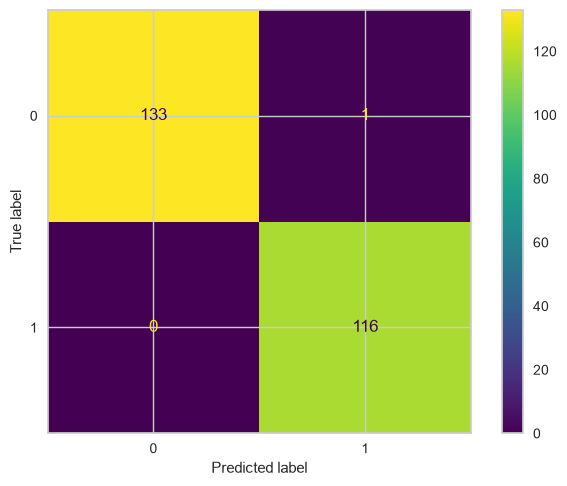

In [15]:
ConfusionMatrixDisplay.from_estimator(clf, features_test, target_test, display_labels=[0, 1])

As you can see, this model performs very well with the defaults, however this was with a synthetic dataset.  One approach you might consider is to use a SQL tokenizer to tokenize the SQL queries before generating embeddings.

```python
sql_tokenizer = Tokenizer()
sql_tokens = sql_tokenizer.tokenize(sql="SELECT * FROM users WHERE username = 'carol' AND password = '5845';")
token_types = [token.token_type.name for token in sql_tokens]
```
This converts the SQL query into the token string below:

```
['SELECT',
 'STAR',
 'FROM',
 'VAR',
 'WHERE',
 'VAR',
 'EQ',
 'STRING',
 'AND',
 'VAR',
 'EQ',
 'STRING',
 'SEMICOLON']
```
You could then generate embeddings from the token sequence.


## Step 4:  Repeat with Real Data
Next, we are going to train another model using a larger, non-generated dataset.  You can find the data in the file `Modified_SQL_Dataset.csv`.   How does this model perform?

In [16]:
raw_data2 = pd.read_csv(f"{DATA_PATH}/Modified_SQL_Dataset.csv")
raw_data2['embedding'] = raw_data2['Query'].apply(lambda x: model.encode(x).tolist())

features2 = np.array(raw_data2['embedding'].tolist())
target2 = raw_data2['Label']

# Split into train/test
features2_train, features2_test, target2_train, target2_test = train_test_split(features2, target2, test_size=0.25)

In [18]:
clf2 = RandomForestClassifier()
clf2.fit(features2_train, target2_train)
predictions2 = clf2.predict(features2_test)

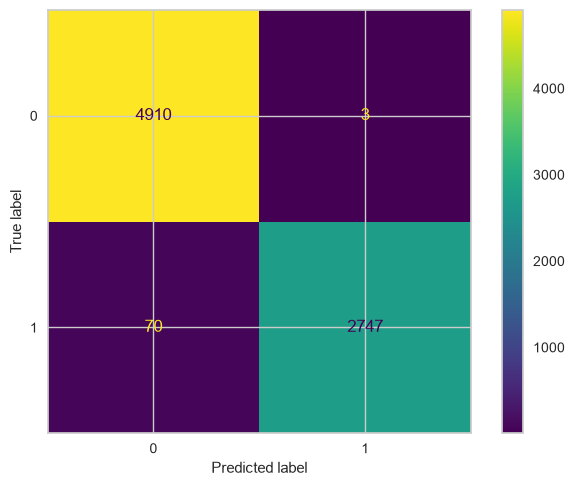

In [19]:
ConfusionMatrixDisplay.from_estimator(clf2, features2_test, target2_test, display_labels=[0, 1])

In [20]:
print(classification_report(target2_test, predictions2, target_names=["safe", "injection"]))

              precision    recall  f1-score   support

        safe       0.99      1.00      0.99      4913
   injection       1.00      0.98      0.99      2817

    accuracy                           0.99      7730
   macro avg       0.99      0.99      0.99      7730
weighted avg       0.99      0.99      0.99      7730



## Try It Yourself
The code below is a wrapper function which allows a user to pass a SQL query to the model to see whether the model labels it as malicious or not.  Try it out and see how it does.

In [21]:
def is_possible_malicious_query(query: str, classifier) -> bool:
    df = pd.DataFrame(columns=['Query'])
    df['Query'] = [query]
    df['embedding'] = df['Query'].apply(lambda x: model.encode(query).tolist())
    embedding = np.array(df['embedding'].tolist())
    results = classifier.predict(embedding)
    return results[0]


In [22]:
print(is_possible_malicious_query("SELECT * FROM users WHERE username = 'carol' AND password = '5845' OR 1=1;", clf2))
print(is_possible_malicious_query("SELECT * FROM users WHERE username = 'carol' AND password = '5845'", clf2))

1
0
